# S1·LUN — El puente generativo: de Naive Bayes a la autorregresión

**Semana 1 · Lunes**

En este notebook construyes tres modelos generativos en orden de complejidad:

1. **Naive Bayes** usado *al revés*: generar texto desde P(x|y)
2. **GMM**: generar puntos desde una mezcla de gaussianas
3. **Bigramas**: tu primer modelo *autorregresivo* — un "GPT de contexto 1"

Todo corre local, sin API keys. Requisitos: `numpy`, `scikit-learn`, `matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## Parte 1 — Naive Bayes como modelo GENERATIVO

Entrenamos el clásico clasificador de spam, pero lo usamos al revés:
muestreamos palabras de P(palabra | clase=spam) para "generar" un email.

Corpus de juguete (en producción usarías miles de emails reales):

In [2]:
spam = [
    "gana dinero gratis ahora haz clic aqui",
    "oferta exclusiva gratis compra ahora descuento increible",
    "haz clic gana premio dinero facil ahora",
    "descuento increible oferta gratis compra ya",
    "premio gratis haz clic ahora dinero",
]
ham = [
    "la reunion del proyecto es el martes a las diez",
    "adjunto el informe de avance del modelo",
    "podemos revisar el codigo del pipeline manana",
    "el profesor subio las notas del taller al aula virtual",
    "confirmo asistencia a la defensa del proyecto",
]
corpus = spam + ham
etiquetas = ["spam"] * len(spam) + ["ham"] * len(ham)

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

vec = CountVectorizer()
X = vec.fit_transform(corpus)
nb = MultinomialNB()
nb.fit(X, etiquetas)

vocab = np.array(vec.get_feature_names_out())
print(f"Vocabulario: {len(vocab)} palabras")
print("Clasifica 'gana premio gratis':", nb.predict(vec.transform(["gana premio gratis"]))[0])

Vocabulario: 44 palabras
Clasifica 'gana premio gratis': spam


El modelo internamente guarda **log P(palabra | clase)** — eso ES la parte generativa.
`feature_log_prob_[i]` es la distribución de palabras de la clase i.

### ✏️ Ejercicio 1.1 — Genera "emails" de spam

Completa la función: muestrea `n_palabras` del vocabulario usando P(palabra|spam)
como pesos (`rng.choice` acepta un argumento `p=`).

In [10]:
# Ejercicio 1.1 — muestrear de P(palabra | clase)
# Pista: idx_clase = list(nb.classes_).index("spam"); probs = np.exp(nb.feature_log_prob_[idx_clase])
def muestrar_spam(n_palabras,rng):
    idx_clase=list(nb.classes_).index("spam")
    probs=np.exp(nb.feature_log_prob_[idx_clase])
    return rng.choice(
        vocab,
        size=n_palabras,
        p=probs
    )
resultado = muestrar_spam(15, rng)
print(" ".join(muestrar_spam(15, rng)))

compra gratis ahora pipeline haz modelo diez virtual profesor notas clic exclusiva ahora avance increible


**Observa:** las palabras son las correctas ("gratis", "clic", "dinero"…) pero el
orden es incoherente. Naive Bayes asume que cada palabra se genera
**independientemente** dada la clase → no sabe nada de secuencias.
Esa es la limitación que motiva los modelos secuenciales.

## Parte 2 — GMM: variables latentes continuas

Un Gaussian Mixture Model define P(X) = Σₖ πₖ·N(X|μₖ,Σₖ).
Generar una muestra = (1) elegir componente z ~ Categórica(π), (2) muestrear x ~ N(μ_z, Σ_z).

In [9]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

X2d, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.1, random_state=7)
gmm = GaussianMixture(n_components=3, random_state=7).fit(X2d)
print("Pesos de mezcla π:", gmm.weights_.round(2))

Pesos de mezcla π: [0.34 0.33 0.33]


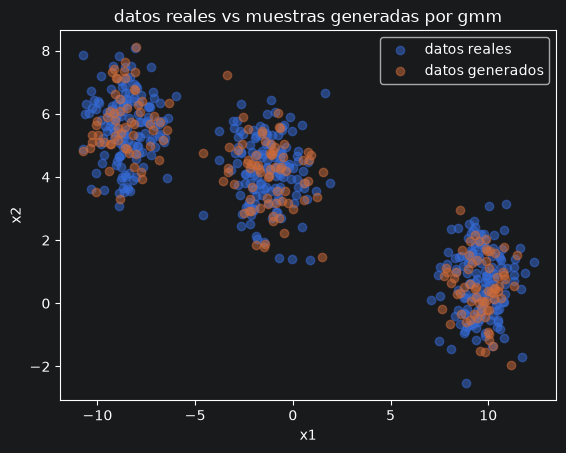

In [11]:
# Ejercicio 2.1 — genera 200 puntos NUEVOS con gmm.sample() y grafícalos
# junto a los datos reales (dos colores). ¿Se parecen las nubes?
X_nuevo,_=gmm.sample(200)
# graficar datos originales
plt.scatter(X2d[:,0],X2d[:,1],alpha=0.5, label="datos reales")
# datos generados por el gmm
plt.scatter(X_nuevo[:,0],X_nuevo[:,1],alpha=0.5, label="datos generados")

plt.legend()
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("datos reales vs muestras generadas por gmm")
plt.show()



La variable latente z (qué componente generó cada punto) nunca se observa: se
infiere con EM. Guarda esta idea — el VAE la generaliza con un espacio latente
aprendido por una red, y los embeddings de la Semana 2 son primos de ese espacio.

## Parte 3 — Tu primer modelo AUTORREGRESIVO: bigramas

La factorización de un LLM: P(x₁…xₙ) = ∏ P(xₜ | x₁…xₜ₋₁).
Un modelo de **bigramas** trunca el contexto a 1 token: P(xₜ | xₜ₋₁).
Lo estimamos contando pares consecutivos en un corpus.

In [12]:
texto = """
el modelo aprende de los datos y el modelo genera texto nuevo
los datos entrenan el modelo y el modelo predice el siguiente token
el siguiente token depende del contexto y el contexto define la probabilidad
la probabilidad de cada token depende de los tokens anteriores
el transformer procesa todos los tokens anteriores sin cuello de botella
"""
tokens = texto.split()
print(f"{len(tokens)} tokens, {len(set(tokens))} únicos")

57 tokens, 29 únicos


In [13]:
# Ejercicio 3.1 — construye la tabla de conteos de bigramas:
# conteos[w1][w2] = cuántas veces w2 sigue a w1 en el corpus.
# Pista: usa collections.defaultdict(Counter) y recorre zip(tokens, tokens[1:])
from collections import defaultdict, Counter
conteos=defaultdict(Counter)
for w1,w2 in zip(tokens,tokens[1:]):
    conteos[w1][w2] +=1


In [15]:
# Ejercicio 3.2 — genera texto: empieza en una palabra y muestrea el siguiente
# token de P(x_t | x_{t-1}) durante 20 pasos.

def generar_texto(inicio,n_pasos=20):
    actual = inicio
    resultado= [actual]
    for _ in range(n_pasos):
        siguientes=list(conteos[actual].keys())
        frecuencias=np.array(list(conteos[actual].values()))
        if len(siguientes)==0:
            break
        probs=frecuencias/frecuencias.sum()
        actual=rng.choice(siguientes,p=probs)
        resultado.append(actual)

    return " ".join(resultado)

print(generar_texto("el", 20))

el siguiente token el modelo genera texto nuevo los datos entrenan el contexto define la probabilidad de los datos entrenan el


¡Es texto (casi) legible! Y lo generaste con la **misma receta que usa GPT**:
predecir el siguiente token dado el contexto, una y otra vez.

### 🤔 Pregunta de cierre (responde en la celda siguiente)

¿Qué le falta a este modelo de bigramas para ser un GPT? Menciona al menos tres cosas.

In [ ]:
# Escribe aquí tu respuesta como comentario:
# le falta tener contexto ver mas palabras antes
# entender mejor las relaciones entre las palabras
# aprender de mucho mas texto


## Resumen

| Modelo | Factorización | Qué aprendimos |
|---|---|---|
| Naive Bayes | P(Y)·∏P(xᵢ|Y) | generativo ≠ coherente: la independencia rompe el orden |
| GMM | Σ πₖ·N(μₖ,Σₖ) | variables latentes: estructura oculta inferida de datos |
| Bigramas | ∏P(xₜ|xₜ₋₁) | la receta autorregresiva de GPT, en miniatura |

**Mañana:** la arquitectura que permite condicionar en *todo* el contexto sin
cuello de botella — el transformer y su mecanismo de atención.